# <<Author: Amir Hossein Najafi - June 2026>>


# 1.Introduction


# 2.Problem Definition and Project Goal

# 3.Data Description


# 4.Exploratory Data Analysis (EDA)


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy import stats

## 4.1 Initial Data Inspection

### 4.1.1 Loading Data and Displaying the First Few Rows

In [1]:
import pandas as pd

In [2]:
# Load the dataset from CSV file
df = pd.read_csv("advertising_Dataset.csv")

In [3]:
# Display the first 5 rows of the dataset
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### 4.1.2 Inspecting Data Structure


In [4]:
# Display dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


### 4.1.3 Checking for Missing Data


In [5]:
# Check for missing values in each column
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

### 4.1.4 Dropping the ID Column


In [6]:
# Remove the index column which is not needed for analysis
df = df.drop(columns=["Unnamed: 0"])

In [7]:
# Display the first rows after removing the column
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 4.2 Descriptive Statistics


### 4.2.1 Calculating Descriptive Statistics


In [8]:
# Generate descriptive statistics for numerical variables
df.describe()


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## 4.3 Visual Analysis with Histograms


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Set the style for the plots
sns.set(style="whitegrid")

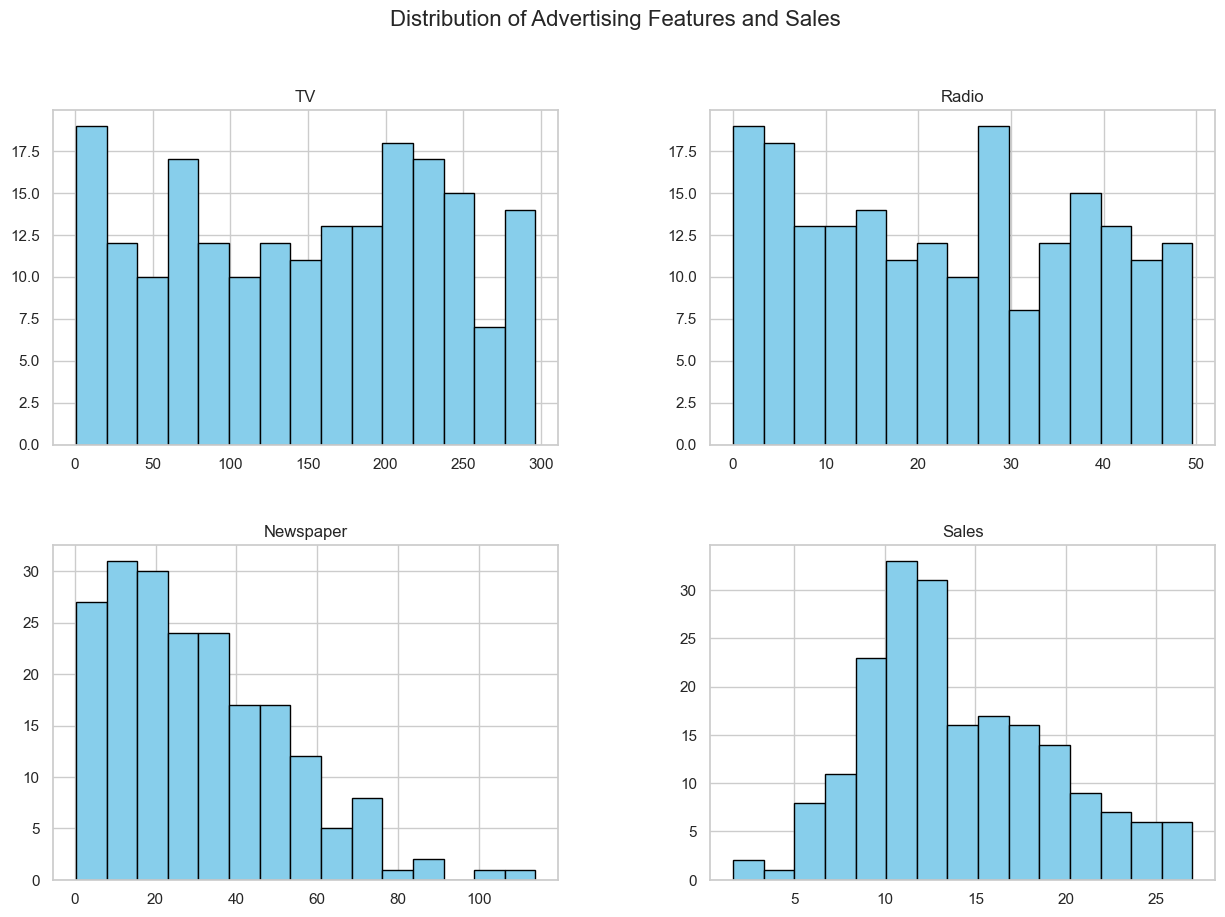

In [12]:
# Create histograms for all columns to visualize distributions
df.hist(bins=15, figsize=(15, 10), color='skyblue', edgecolor='black')
# Add a title to the overall figure
plt.suptitle("Distribution of Advertising Features and Sales", fontsize=16)
plt.show()

### 4.4 Identifying Outliers with Boxplots


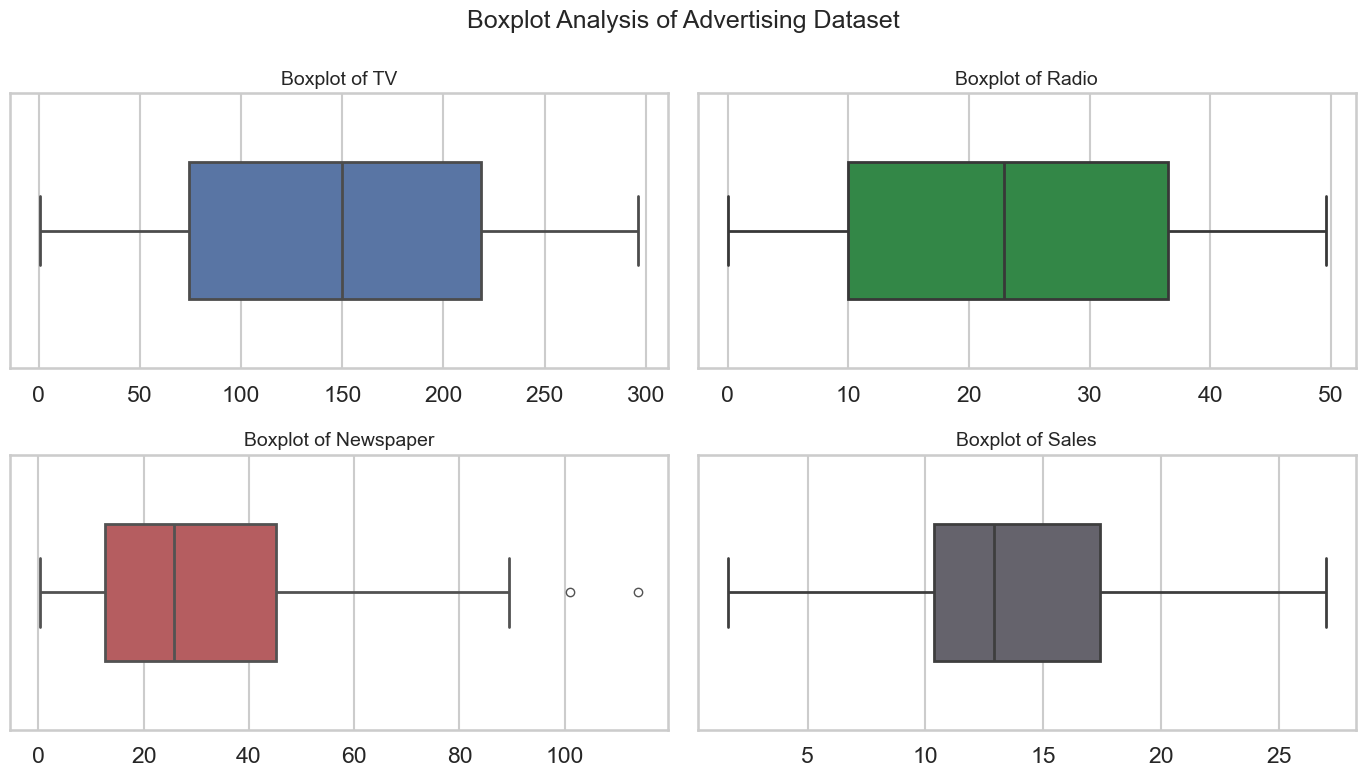

In [26]:
# Style for nicer plots
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(14,8))

columns = df.columns
colors = ["#4C72B0", "#25953F", "#C44E52", "#64626D"]

for i, col in enumerate(columns):
    plt.subplot(2,2,i+1)
    sns.boxplot(
        x=df[col],
        color=colors[i],
        width=0.5,
        fliersize=6,
        linewidth=2
    )
    plt.title(f"Boxplot of {col}", fontsize=14)
    plt.xlabel("")

plt.suptitle("Boxplot Analysis of Advertising Dataset", fontsize=18)

plt.tight_layout()
plt.show()

## 4.5 Correlation Analysis


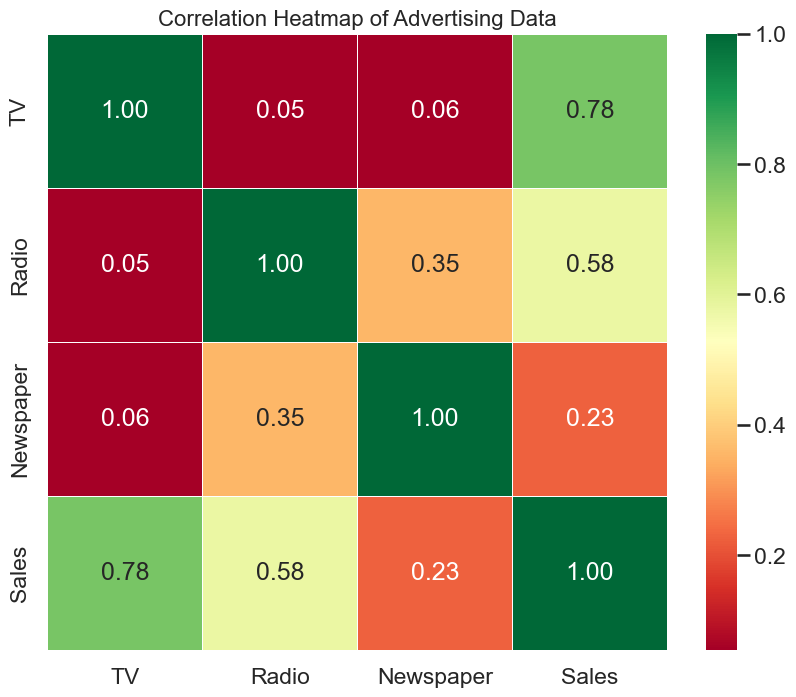

In [27]:
# Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Advertising Data', fontsize=16)
plt.show()


# 5. Matrix Analysis and Dimensionality Reduction


## 5.1 Calculating the Covariance Matrix for Advertising Costs


In [34]:
# Selecting the features: TV, Radio, and Newspaper
X_raw = df[['TV', 'Radio', 'Newspaper']]

# Calculating the covariance matrix (using .T because np.cov expects variables in rows)
cov_matrix = np.cov(X_raw.T)

print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[7370.94989322   69.86249246  105.91945226]
 [  69.86249246  220.42774271  114.49697889]
 [ 105.91945226  114.49697889  474.30832563]]


## 5.2 Computing Eigenvalues and Eigenvectors


In [36]:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Display the results
print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)


Eigenvalues:
[7373.2933766   516.07662595  176.31595901]

Eigenvectors:
[[ 0.99982947  0.01807077  0.00380577]
 [ 0.01001377 -0.35736234 -0.93391214]
 [ 0.01551648 -0.93379098  0.35748236]]


## 5.3 Performing SVD on Standardized Data


In [37]:
from sklearn.preprocessing import StandardScaler
import numpy as np

In [40]:
# Select advertising expense features
X_raw = df[['TV', 'Radio', 'Newspaper']]

# Standardize the features to remove the effect of different scales
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Perform Singular Value Decomposition on the standardized data
U, S, VT = np.linalg.svd(X_scaled, full_matrices=False)

# Display the singular values and right singular vectors
print("Singular Values:")
print(S)

print("\nVT Matrix:")
print(VT)


Singular Values:
[16.55809475 14.02323885 11.3656619 ]

VT Matrix:
[[-0.20787391 -0.69139674 -0.69192412]
 [-0.97814838  0.14965532  0.14432267]
 [ 0.0037659   0.70680537 -0.70739804]]


## 5.4 Calculating Explained Variance Ratio


In [41]:
# Variance is proportional to the square of singular values
squared_sv = S**2
total_variance = np.sum(squared_sv)
explained_variance_ratio = squared_sv / total_variance

print("Explained Variance Ratio:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

# Calculate cumulative variance
cumulative_variance = np.cumsum(explained_variance_ratio)
print("\nCumulative Explained Variance:")
print(cumulative_variance)


Explained Variance Ratio:
Principal Component 1: 0.4570 (45.70%)
Principal Component 2: 0.3278 (32.78%)
Principal Component 3: 0.2153 (21.53%)

Cumulative Explained Variance:
[0.45695084 0.78470288 1.        ]


# 6. Linear Regression Modeling


## 6.1 Model Definition and Design Matrix Preparation


In [42]:
import numpy as np

# Display basic information about the existing dataframe
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

# Select independent variables
X_raw = df[['TV', 'Radio', 'Newspaper']].values

# Select dependent variable
y = df['Sales'].values

# Add intercept column to design matrix
# This column represents Beta_0 in the regression model
ones_column = np.ones((X_raw.shape[0], 1))
X = np.hstack((ones_column, X_raw))

print("\nRaw feature matrix shape:", X_raw.shape)
print("Design matrix X shape:", X.shape)
print("Response vector y shape:", y.shape)

print("\nFirst 5 rows of design matrix X:")
print(X[:5])

print("\nFirst 5 values of response vector y:")
print(y[:5])


Dataset shape: (200, 4)

Columns:
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

First 5 rows:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

Raw feature matrix shape: (200, 3)
Design matrix X shape: (200, 4)
Response vector y shape: (200,)

First 5 rows of design matrix X:
[[  1.  230.1  37.8  69.2]
 [  1.   44.5  39.3  45.1]
 [  1.   17.2  45.9  69.3]
 [  1.  151.5  41.3  58.5]
 [  1.  180.8  10.8  58.4]]

First 5 values of response vector y:
[22.1 10.4  9.3 18.5 12.9]


## 6.2 Computing Model Coefficients using Least Squares and SVD Pseudo-inverse


### 6.2.1 Method 1: Calculating Coefficients Using the Normal Equation


In [43]:
# beta = (X^T X)^(-1) X^T y
beta_normal = np.linalg.inv(X.T @ X) @ X.T @ y

# Display results
labels = ['Beta 0 - Intercept', 'Beta 1 - TV', 'Beta 2 - Radio', 'Beta 3 - Newspaper']

print("Beta coefficients using Normal Equation:")
for label, value in zip(labels, beta_normal):
    print(f"{label}: {value:.6f}")

Beta coefficients using Normal Equation:
Beta 0 - Intercept: 2.938889
Beta 1 - TV: 0.045765
Beta 2 - Radio: 0.188530
Beta 3 - Newspaper: -0.001037


In [44]:
# 1. Singular Value Decomposition
U, s, Vt = np.linalg.svd(X, full_matrices=False)

# 2. Construct Sigma-plus
s_plus = np.zeros_like(s)
s_plus[s > 1e-10] = 1 / s[s > 1e-10]

# 3. Compute pseudo-inverse of X
X_plus = Vt.T @ np.diag(s_plus) @ U.T

# 4. Compute beta coefficients
beta_svd = X_plus @ y

# Display results
labels = ['Beta 0 - Intercept', 'Beta 1 - TV', 'Beta 2 - Radio', 'Beta 3 - Newspaper']

print("Beta coefficients using SVD-based Pseudo-inverse:")
for label, value in zip(labels, beta_svd):
    print(f"{label}: {value:.6f}")

Beta coefficients using SVD-based Pseudo-inverse:
Beta 0 - Intercept: 2.938889
Beta 1 - TV: 0.045765
Beta 2 - Radio: 0.188530
Beta 3 - Newspaper: -0.001037


In [45]:
print("Comparison of coefficients:")
for label, b1, b2 in zip(labels, beta_normal, beta_svd):
    print(f"{label}: Normal = {b1:.6f} | SVD = {b2:.6f} | Difference = {abs(b1-b2):.10f}")


Comparison of coefficients:
Beta 0 - Intercept: Normal = 2.938889 | SVD = 2.938889 | Difference = 0.0000000000
Beta 1 - TV: Normal = 0.045765 | SVD = 0.045765 | Difference = 0.0000000000
Beta 2 - Radio: Normal = 0.188530 | SVD = 0.188530 | Difference = 0.0000000000
Beta 3 - Newspaper: Normal = -0.001037 | SVD = -0.001037 | Difference = 0.0000000000


# 6.3 Calculating the Standard Errors of the Coefficients


In [46]:
# Define feature matrix and target vector
X = df[["TV", "Radio", "Newspaper"]].values
y = df["Sales"].values.reshape(-1, 1)

# Add intercept term
X_design = np.hstack([np.ones((X.shape[0], 1)), X])

# Estimate coefficients using normal equation
beta_hat = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y

# Predicted values
y_hat = X_design @ beta_hat

# Residuals
residuals = y - y_hat

# Sample size and number of parameters
n = X_design.shape[0]
p = X_design.shape[1]

# Residual Sum of Squares
RSS = residuals.T @ residuals

# Estimate of error variance
sigma2_hat = RSS / (n - p)

# Covariance matrix of coefficients
cov_beta = sigma2_hat[0, 0] * np.linalg.inv(X_design.T @ X_design)

# Standard errors of coefficients
standard_errors = np.sqrt(np.diag(cov_beta))

# Show results
coef_names = ["Intercept", "TV", "Radio", "Newspaper"]

results_df = pd.DataFrame({
    "Coefficient": coef_names,
    "Estimate": beta_hat.flatten(),
    "Std_Error": standard_errors
})

print("Residual Sum of Squares (RSS):")
print(RSS)

print("\nEstimated Error Variance (sigma^2):")
print(sigma2_hat)

print("\nCovariance Matrix of Coefficients:")
print(cov_beta)

print("\nCoefficients and Standard Errors:")
print(results_df)

Residual Sum of Squares (RSS):
[[556.8252629]]

Estimated Error Variance (sigma^2):
[[2.84094522]]

Covariance Matrix of Coefficients:
[[ 9.72867479e-02 -2.65727337e-04 -1.11548946e-03 -5.91021239e-04]
 [-2.65727337e-04  1.94573710e-06 -4.47039463e-07 -3.26595026e-07]
 [-1.11548946e-03 -4.47039463e-07  7.41533504e-05 -1.78006245e-05]
 [-5.91021239e-04 -3.26595026e-07 -1.78006245e-05  3.44687543e-05]]

Coefficients and Standard Errors:
  Coefficient  Estimate  Std_Error
0   Intercept  2.938889   0.311908
1          TV  0.045765   0.001395
2       Radio  0.188530   0.008611
3   Newspaper -0.001037   0.005871


## 6.4 t-test for Regression Coefficients


In [47]:
# estimated coefficients
beta_hat = np.array([2.938889, 0.045765, 0.188530, -0.001037])

# standard errors
std_err = np.array([0.311908, 0.001395, 0.008611, 0.005871])

# t statistics
t_stats = beta_hat / std_err
t_stats

array([ 9.42229439, 32.80645161, 21.89408896, -0.1766309 ])

## 6.5 Calculating p-values for the Coefficients


In [49]:
from scipy import stats

In [50]:
# t statistics from previous step
t_stats = np.array([9.42, 32.81, 21.89, -0.18])

# degrees of freedom
n = 200
p = 4
df = n - p

# two-tailed p-values
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df))

p_values


array([0.        , 0.        , 0.        , 0.85733853])

# 7. Bayesian Inference


## 7.1 Defining High Sales Based on the Median


In [52]:
# محاسبه میانه فروش
median_sales = df["Sales"].median()

# تعریف فروش بالا: فروش بیشتر از میانه
high_sales = df["Sales"] > median_sales

# تعداد نمونه‌های فروش بالا
num_high_sales = high_sales.sum()

# تعداد کل نمونه‌ها
n = len(df)

median_sales, num_high_sales, n


(12.9, 98, 200)

## 7.2 Updating the Beta Distribution


In [53]:
# prior parameters
alpha_prior = 1
beta_prior = 1

# observed data
x = num_high_sales
n = len(df)

# posterior parameters
alpha_post = alpha_prior + x
beta_post = beta_prior + (n - x)

alpha_post, beta_post


(99, 103)

                                                   THe End                                                                                                                                                               